# Data Loading & Date Parsing

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load Data

In [3]:
df = pd.read_csv("../data/kenya.csv")  # replace with your file
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## Add Country Column

In [4]:
df["Country"] = "Kenya"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


## Convert the YEAR and DOY columns into datetime column

In [5]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.drop(columns=["YEAR", "DOY"], inplace=True)
df.rename(columns={"date": "YEAR"}, inplace=True)
df.tail()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR
4103,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27
4104,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28
4105,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29
4106,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30
4107,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40,Kenya,2026-03-31


## Extract Month

In [6]:
df["month"] = df["YEAR"].dt.month
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR,month
0,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


# Summary Statistics & Missing-Value Report

## Replace all occurrences of -999 with np.nan

In [7]:
df = df.replace(-999, np.nan)

## drop any duplicate rows

In [8]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M, Country, YEAR, month]
Index: []


In [9]:
df.describe(include="number")

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564
std,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046
min,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000
25%,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000
50%,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000
75%,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000
max,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000


Key Takeaways

The dataset shows a moderate climate with an average temperature of ~16°C and significant daily temperature variation (~13°C). Precipitation is highly skewed, with many dry days and occasional extreme rainfall events (up to 82 mm), indicating seasonal rainfall patterns. Humidity varies widely, suggesting changing atmospheric conditions across time. Wind speeds are generally low, while atmospheric pressure remains stable, indicating consistent elevation or weather conditions. The dataset appears complete with no missing values.

## missing values per column

In [13]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
YEAR           0
month          0
dtype: int64

In [14]:
missing_percent = (df.isna().sum() / len(df)) * 100
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

Interpretation of Missing Data (>5%)

Columns with **more than 5% missing values** may indicate issues in **data collection, sensor failure, or incomplete records**.

Key implications:
- Missing **precipitation data** could bias rainfall analysis and lead to incorrect conclusions about wet and dry seasons.
- Missing **temperature values** may distort seasonal trends and affect climate pattern interpretation.
- Missing **humidity or wind data** can reduce the reliability of atmospheric condition analysis.

Recommended handling:
- **Imputation** (mean, median, interpolation) for moderate missingness
- **Removal** if the column is not critical or has excessive missing data
- **Careful evaluation** before deciding, based on the importance of the variable in analysis or modeling

Overall, columns with high missingness should be treated carefully to avoid introducing bias into the analysis.

# Outlier Detection & Basic Cleaning

## Compute Z-scores

In [19]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
# Compute Z-scores
z_scores = df[cols].apply(stats.zscore)
z_scores

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.602229,0.488146,-1.824893,-0.461709,-2.066383,0.068262,0.387848
1,-0.553639,0.818867,-2.566670,-0.461709,-2.726809,0.197201,-0.025444
2,-0.019158,1.158068,-2.093345,-0.461709,-2.425792,0.466802,0.307206
3,0.626385,1.425189,-1.167890,0.635830,-1.406964,-0.904645,-0.378254
4,-0.012217,0.712866,-1.620021,0.101212,-1.792548,-1.514176,-0.327852
...,...,...,...,...,...,...,...
4103,-0.734114,-1.034019,0.506408,0.377955,1.623343,-0.693653,-0.479057
4104,-0.532815,-0.610018,0.400440,-0.276165,1.163260,-1.268019,-1.013312
4105,-0.491168,-0.550658,-0.185917,-0.203835,1.194469,-1.514176,-1.134276
4106,-0.518933,-0.436178,-0.574468,0.981759,1.353535,-1.232854,-1.063714


### Flag rows where |Z| > 3

In [20]:
# Flag rows where |Z| > 3 in ANY column
outlier_mask = (z_scores.abs() > 3).any(axis=1)
outlier_rows = df[outlier_mask]

# outlier_rows.to_csv("../data/outliers.csv", index=False)

### Count how many rows contain at least one outlier

In [21]:
outlier_counts = (z_scores.abs() > 3).sum()
outlier_counts

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

In [22]:
# Summary report
print("*** Z-Score Outlier Report ***\n")
print("Outliers per column:")
print(outlier_counts.to_string())
print(f"\nTotal rows flagged (outlier in ANY column): {outlier_mask.sum()}")
print(f"Percentage of dataset flagged: {outlier_mask.sum() / len(df) * 100:.2f}%")
print(f"\nFlagged rows preview:")
print(outlier_rows[cols].head(10))

*** Z-Score Outlier Report ***

Outliers per column:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6

Total rows flagged (outlier in ANY column): 121
Percentage of dataset flagged: 2.95%

Flagged rows preview:
       T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX
14   21.24    31.17    12.59         0.00  28.42  3.27      4.78
15   22.95    32.70    14.62         0.00  29.64  2.30      3.41
16   23.00    32.29    15.79         0.00  29.43  2.71      3.91
17   23.38    32.42    13.97         0.16  32.67  1.43      3.07
45   22.14    27.92    18.11        23.09  61.69  0.97      1.97
46   19.65    26.45    14.31        23.12  70.73  1.65      3.42
116  18.97    23.01    16.98        16.45  83.64  1.29      2.77
191  18.27    27.93     9.47         0.00  52.44  2.99      3.98
346  19.23    22.56    15.93        23.14  81.62  1.22      2.57
348  18.87    24.45    14.94        12.77  84.76  1.42      3.

### Outlier Handling Decision (Integrated Analysis)

The outlier analysis shows that **121 rows (2.95%)** of the dataset are flagged as containing at least one outlier. This is a relatively small proportion, suggesting that the dataset is largely clean and stable.

#### 1. Nature of Outliers by Variable
- **PRECTOTCORR (92 outliers)**  
  The majority of outliers come from precipitation. Given the earlier distribution analysis (highly right-skewed with extreme maximum values), these are **expected extreme rainfall events**, not data errors.

- **Temperature variables (T2M, T2M_MAX, T2M_MIN)**  
  Very few outliers (3–9). These likely represent **rare but realistic temperature fluctuations** rather than anomalies.

- **RH2M (humidity)**  
  A small number of low-humidity values (~28–32%) are flagged. These may correspond to **dry atmospheric conditions** and are plausible.

- **Wind variables (WS2M, WS2M_MAX)**  
  Almost no outliers, indicating stable wind behavior.

#### 2. Contextual Interpretation
- The dataset reflects a **climate system with stable temperature but highly variable precipitation**.
- Outliers in rainfall align with **episodic storm events**, which are **important signals**, not noise.
- Removing such values would distort the understanding of **rainfall intensity and seasonality**.

#### 3. Decision
- **Do NOT remove outliers globally.**
- Instead:
  - Keep all data for **climate and seasonal analysis**
  - Apply **log transformation** (e.g., log1p) for PRECTOTCORR in modeling/visualization
  - Optionally use **robust statistics** (median, IQR) instead of mean where needed


## Handle remaining missing values

In [24]:
# Step 1: Define threshold (30% missing)
threshold = int(df.shape[1] * 0.3)

# Step 2: Drop rows with too many missing values
df_cleaned = df[df.isnull().sum(axis=1) <= threshold]

# Step 3: Forward-fill remaining missing values
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


C:\Users\bemnet\AppData\Local\Temp\ipykernel_35492\3189414256.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


## Export the cleaned DataFrame

In [25]:
df_cleaned[weather_cols].to_csv("../data/kenya_clean.csv", index=False)

# Time Series Analysis

In [26]:
df["date"] = pd.to_datetime(df["YEAR"])
# Create Year-Month column
df["year_month"] = df["date"].dt.to_period("M")
# Compute monthly average T2M
monthly_avg = df.groupby("year_month")["T2M"].mean().reset_index()
# Convert back to timestamp for plotting
monthly_avg["year_month"] = monthly_avg["year_month"].dt.to_timestamp()
# Find warmest and coolest months
warmest = monthly_avg.loc[monthly_avg["T2M"].idxmax()]
coolest = monthly_avg.loc[monthly_avg["T2M"].idxmin()]


##  monthly average T2M

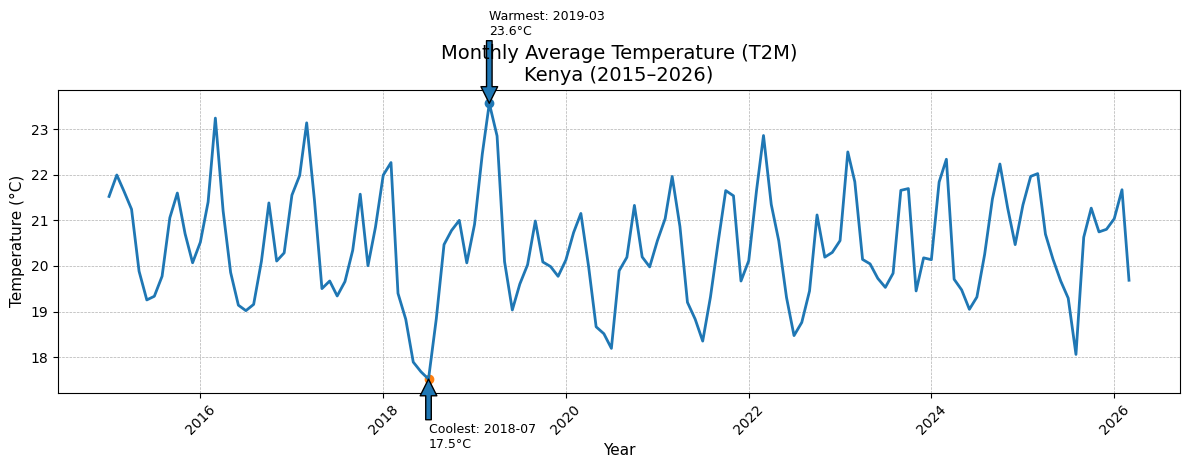

In [28]:

plt.figure(figsize=(12, 5))  # wider for time series

# Line plot
plt.plot(monthly_avg["year_month"], monthly_avg["T2M"], linewidth=2)

# Highlight warmest & coolest points
plt.scatter(warmest["year_month"], warmest["T2M"])
plt.scatter(coolest["year_month"], coolest["T2M"])

# Annotate warmest
plt.annotate(
    f"Warmest: {warmest['year_month'].strftime('%Y-%m')}\n{warmest['T2M']:.1f}°C",
    xy=(warmest["year_month"], warmest["T2M"]),
    xytext=(warmest["year_month"], warmest["T2M"] + 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Annotate coolest
plt.annotate(
    f"Coolest: {coolest['year_month'].strftime('%Y-%m')}\n{coolest['T2M']:.1f}°C",
    xy=(coolest["year_month"], coolest["T2M"]),
    xytext=(coolest["year_month"], coolest["T2M"] - 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Titles and labels
plt.title("Monthly Average Temperature (T2M)\nKenya (2015–2026)", fontsize=14)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)

# Grid for readability
plt.grid(True, linestyle="--", linewidth=0.5)

# Improve x-axis ticks (less crowded)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## monthly total PRECTOTCORR

In [29]:
monthly_rain = df.groupby("year_month")["PRECTOTCORR"].sum().reset_index()

monthly_rain["year_month"] = monthly_rain["year_month"].dt.to_timestamp()
peak_months = monthly_rain.nlargest(2, "PRECTOTCORR")

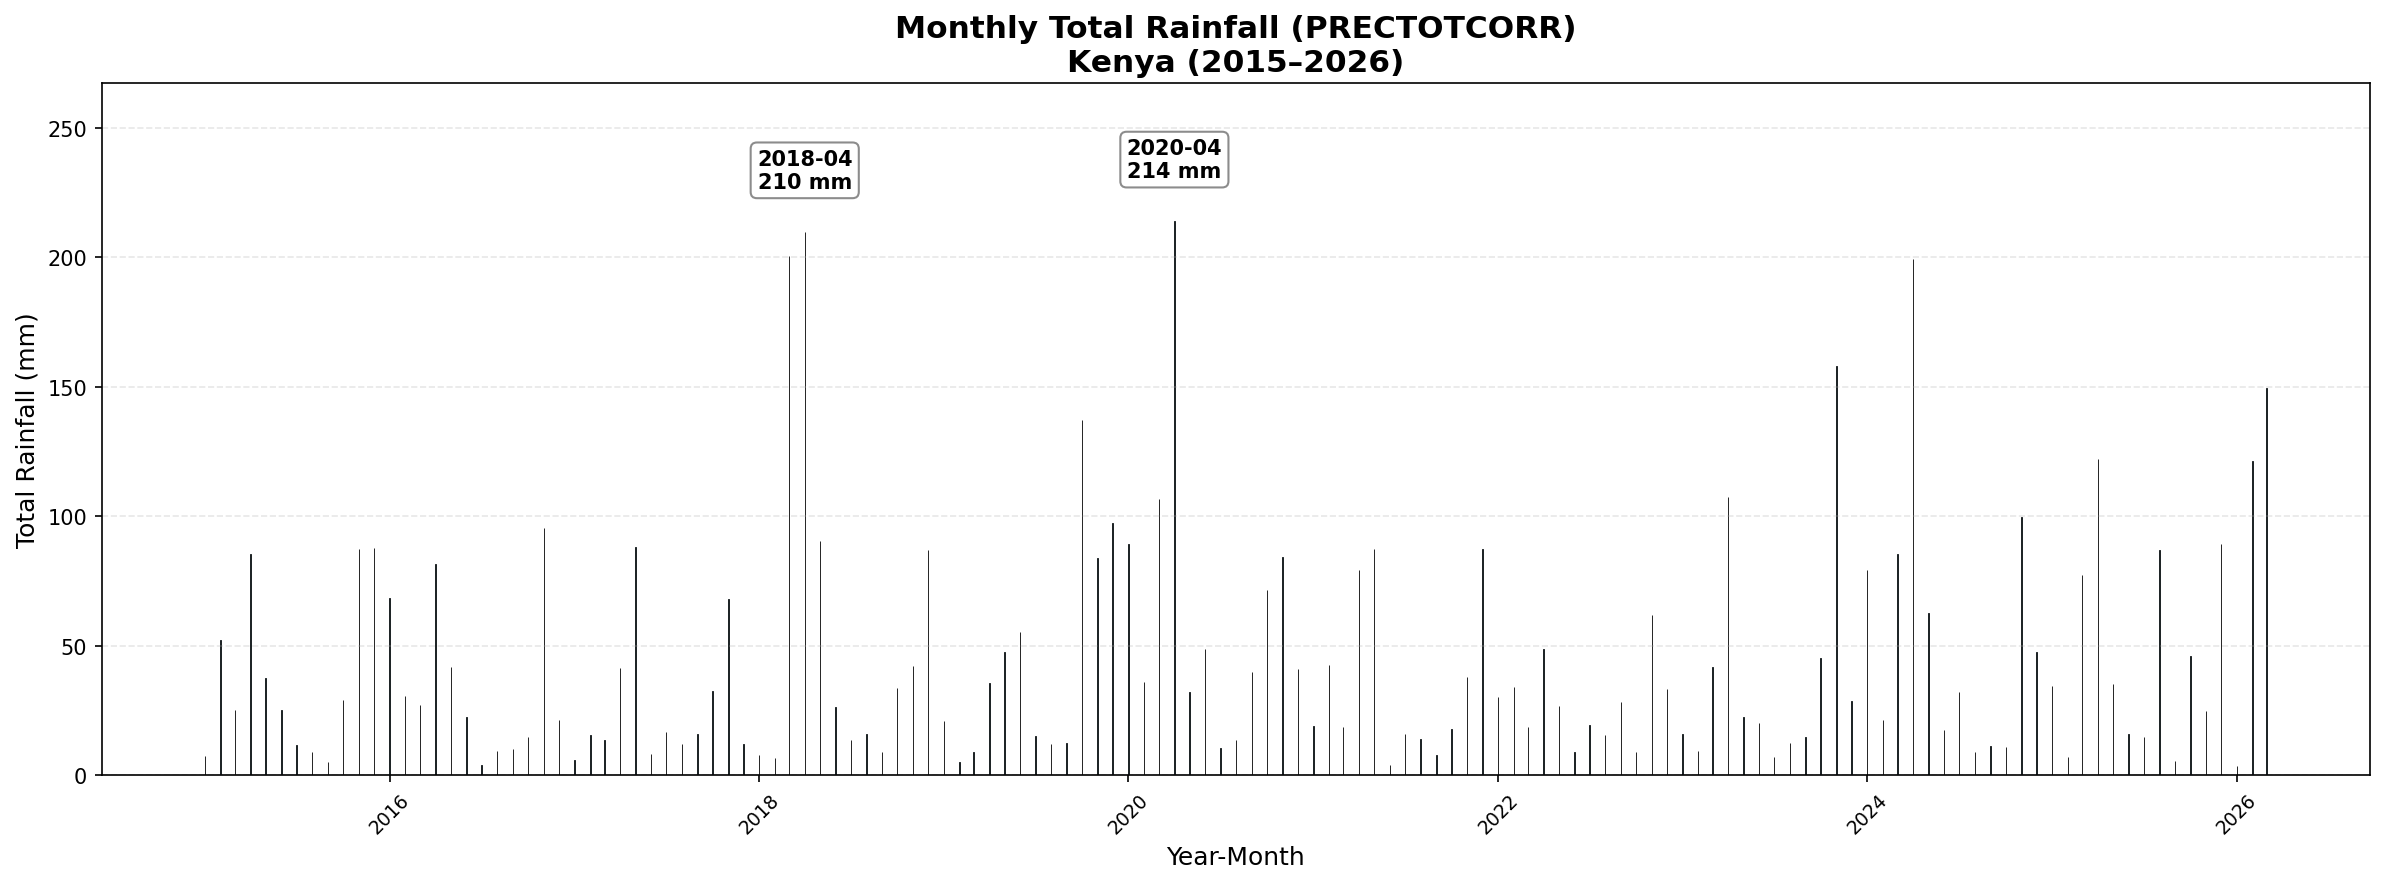

In [31]:
plt.figure(figsize=(16, 6), dpi=150)

monthly_rain_sorted = monthly_rain.sort_values("year_month")

# Base bar plot
plt.bar(
    monthly_rain_sorted["year_month"],
    monthly_rain_sorted["PRECTOTCORR"],
    color="skyblue",
    edgecolor="black",
    linewidth=0.4
)

# Peak months
peak_months = monthly_rain_sorted.nlargest(2, "PRECTOTCORR")

# Dynamic y-limit padding (IMPORTANT FIX)
y_max = monthly_rain_sorted["PRECTOTCORR"].max()
plt.ylim(0, y_max * 1.25)

# Place annotations HIGH ABOVE bars (fixed position logic)
for _, row in peak_months.iterrows():
    plt.text(
        row["year_month"],
        row["PRECTOTCORR"] + (y_max * 0.08),  # always above bar
        f"{row['year_month'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f} mm",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# Styling
plt.title("Monthly Total Rainfall (PRECTOTCORR)\nKenya (2015–2026)",
          fontsize=15, fontweight="bold")

plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)

plt.xticks(rotation=45, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation & Relationship Analysis

## Heatmap of correlations

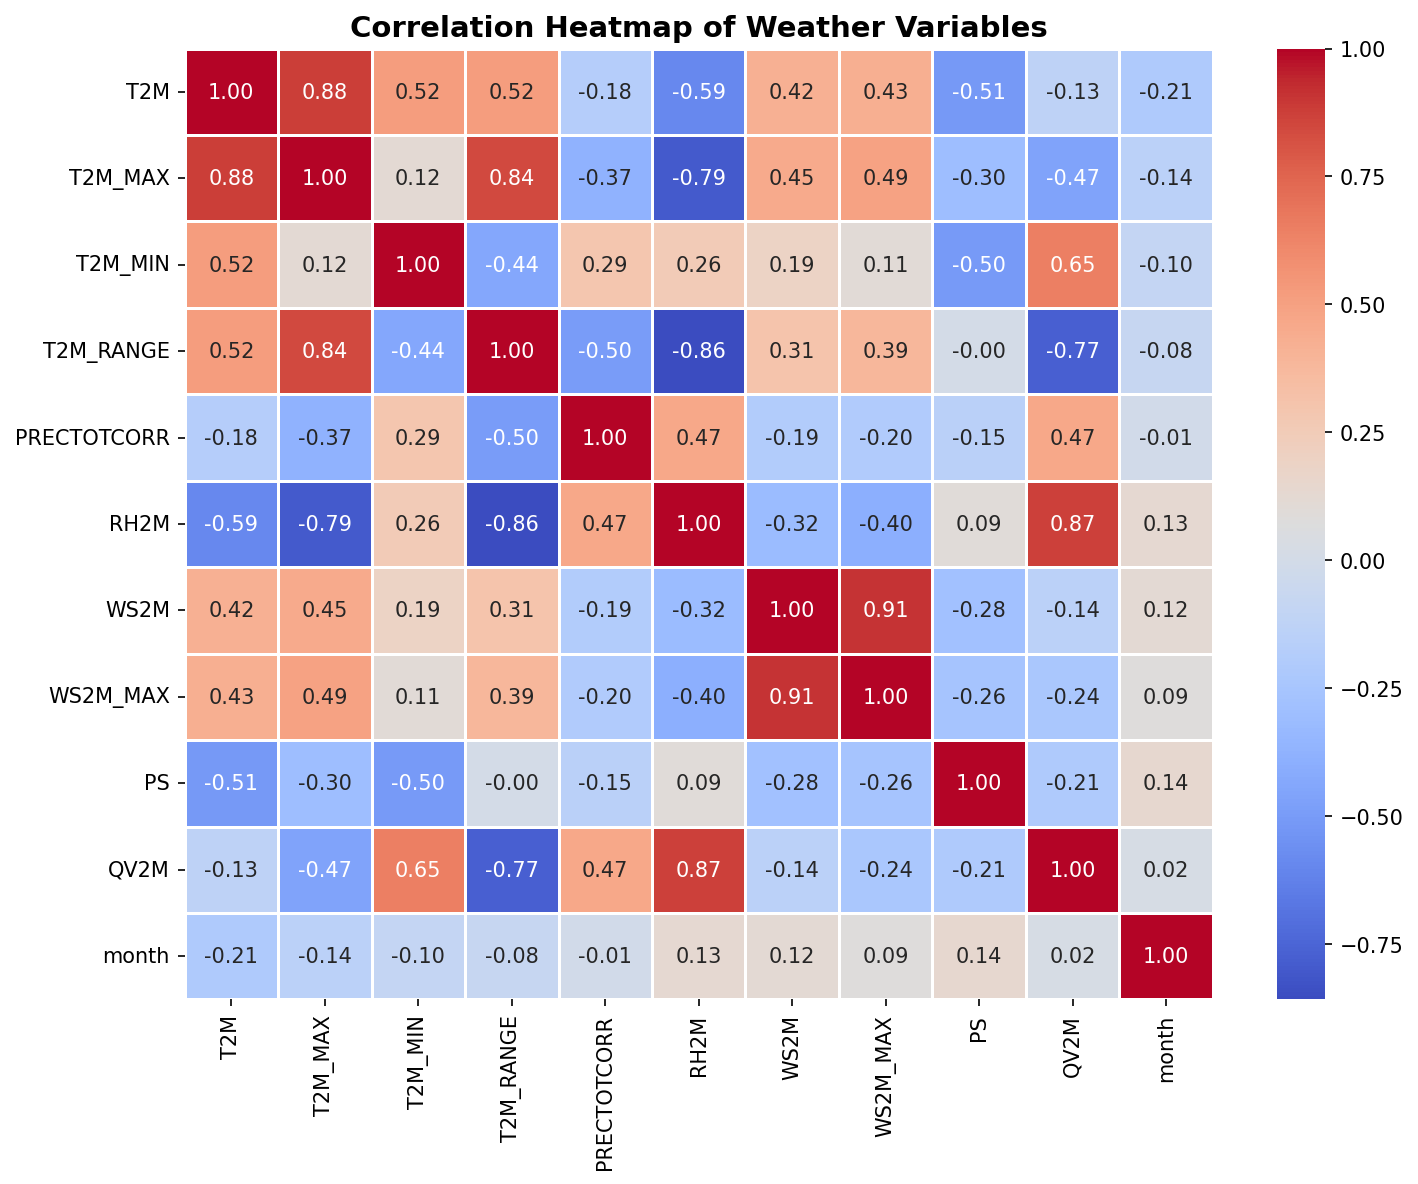

In [32]:
# Select only numeric columns and compute correlation matrix
# This measures how strongly each variable is linearly related to others
corr = df.select_dtypes(include="number").corr()
# Set figure size and resolution for better readability
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap of correlation matrix
sns.heatmap(
    corr,              # correlation values
    annot=True,        # show numerical values inside cells
    fmt=".2f",         # format numbers to 2 decimal places
    cmap="coolwarm",   # color scheme (blue = negative, red = positive)
    linewidths=0.5     # adds spacing between cells for clarity
)

# Add title to the plot
plt.title("Correlation Heatmap of Weather Variables", fontsize=14, fontweight="bold")

# Improve layout so labels don’t overlap
plt.tight_layout()

# Display the plot
plt.show()

## T2M vs RH2M (Temperature vs Humidity)

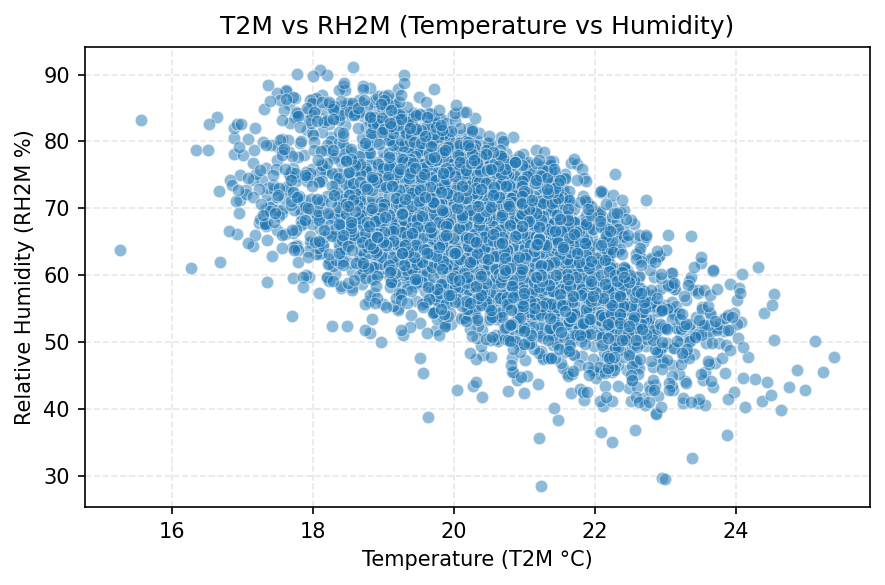

In [33]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    alpha=0.5
)

plt.title("T2M vs RH2M (Temperature vs Humidity)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)

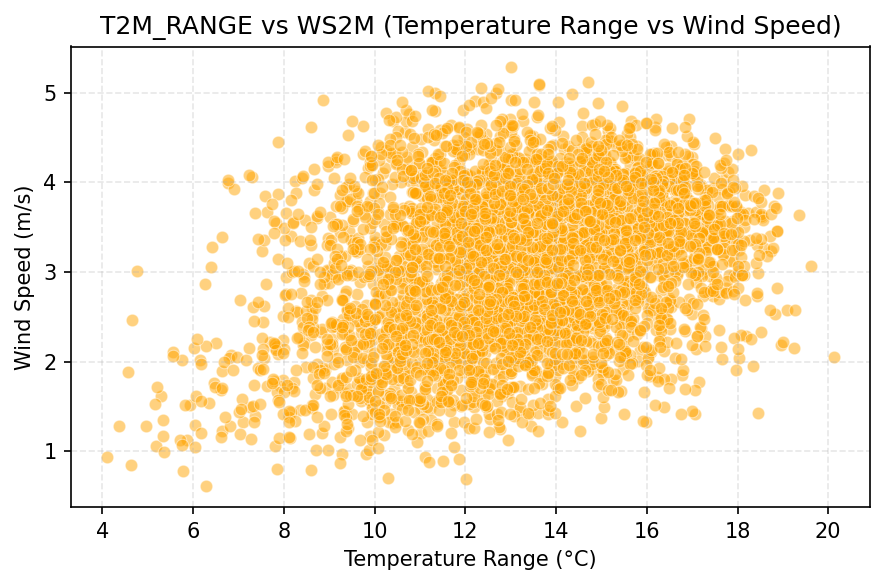

In [34]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M_RANGE",
    y="WS2M",
    alpha=0.5,
    color="orange"
)

plt.title("T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot Insights

- **T2M vs RH2M:**  
  Clear **negative correlation** — as temperature increases, humidity decreases.  
  → Temperature is a **key driver of humidity variation**.

- **T2M_RANGE vs WS2M:**  
  **Weak positive relationship** with high dispersion.  
  → Wind has **limited influence** on temperature variability.

### Overall Insight
> The climate is mainly driven by **temperature–humidity dynamics**, while **wind plays a minor role**.

## Distribution Analysis

### Histogram of PRECTOTCORR

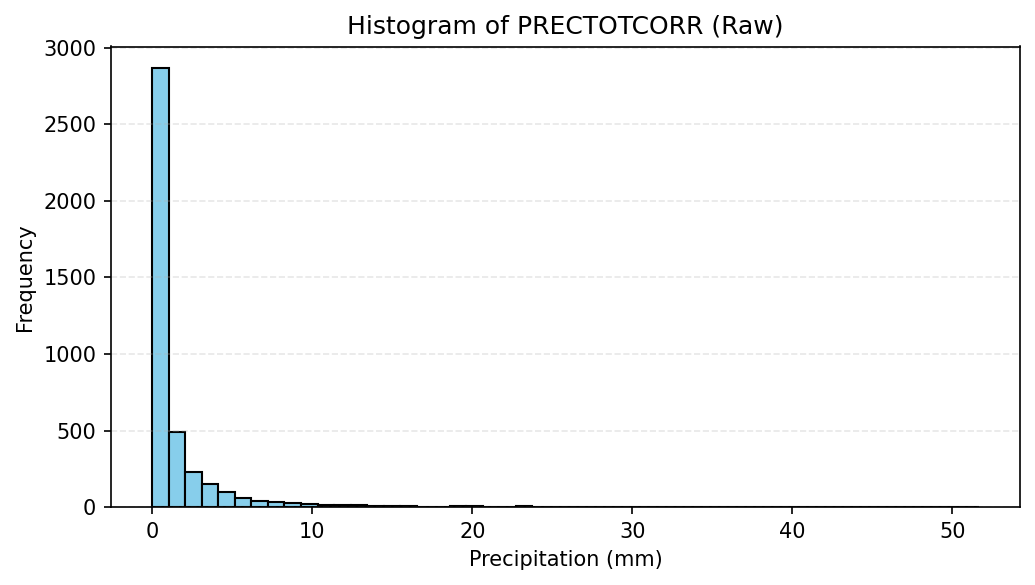

In [35]:
plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR"], bins=50, color="skyblue", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Raw)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Log-Transformed Histogram

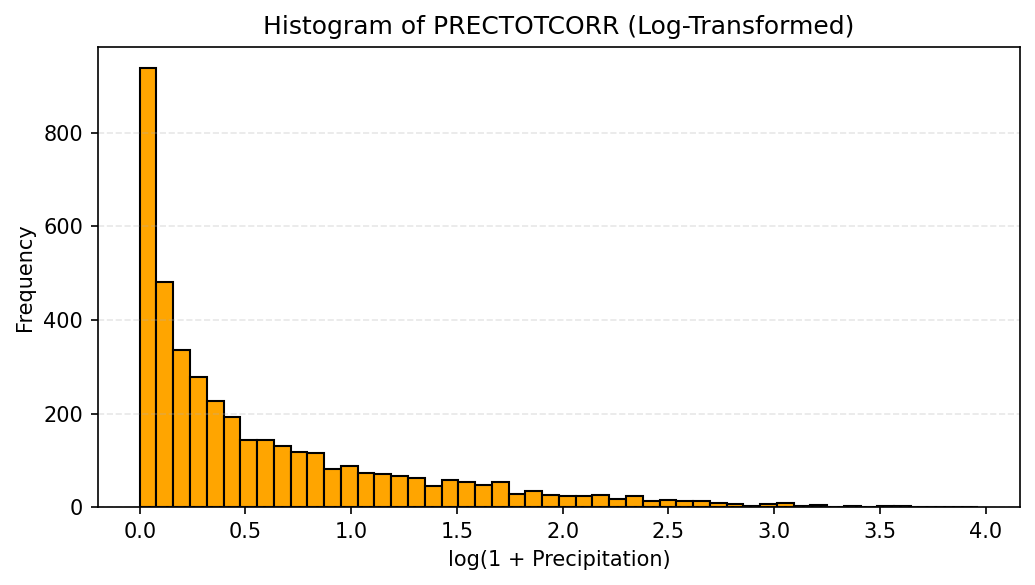

In [36]:
df["PRECTOTCORR_log"] = np.log1p(df["PRECTOTCORR"])

plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR_log"], bins=50, color="orange", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Log-Transformed)")
plt.xlabel("log(1 + Precipitation)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Distribution Analysis of PRECTOTCORR

The rainfall variable (PRECTOTCORR) shows a **strong right-skewed distribution**:

- Most values are concentrated near zero, indicating that many days experience little or no rainfall.
- A small number of extreme values (heavy rainfall events) create a long right tail.
- This confirms that rainfall in the dataset is **episodic rather than uniform**.

After applying a logarithmic transformation:
- The distribution becomes more balanced and closer to normal.
- Extreme rainfall values are compressed, making patterns easier to analyze.

###  Conclusion:
- The original distribution is highly skewed (non-normal)
- Log transformation is recommended for modeling or statistical analysis
- Rainfall behavior is dominated by rare but intense events

### Bubble Chart: T2M vs RH2M (size = PRECTOTCORR)

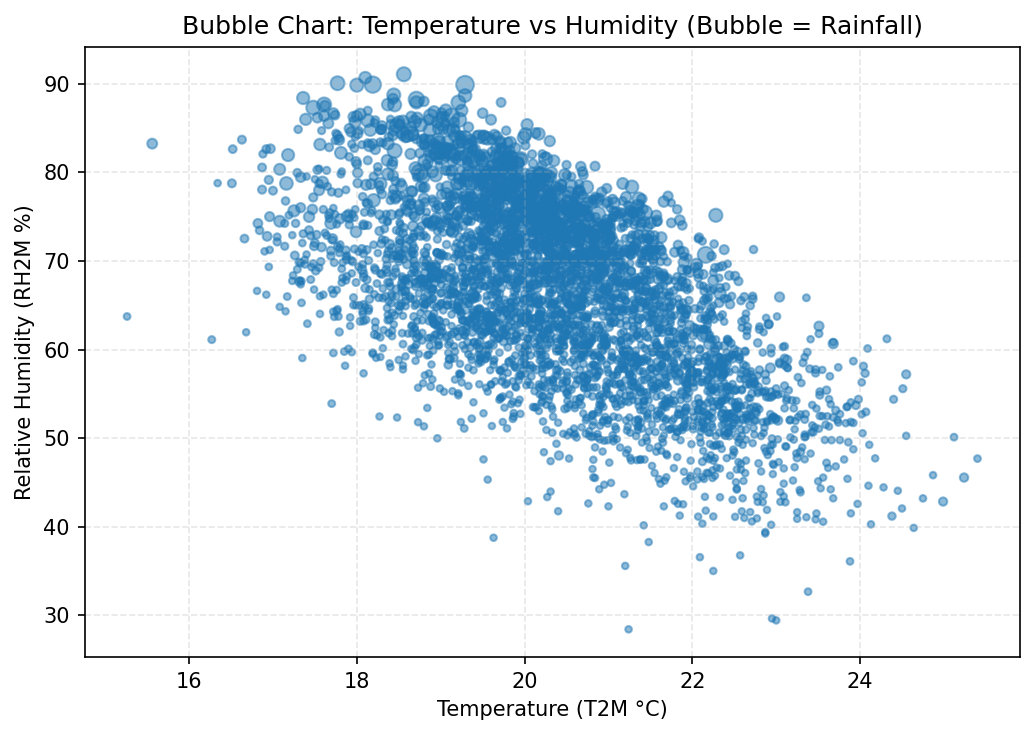

In [37]:
plt.figure(figsize=(7,5), dpi=150)

# Scale bubble size (important: rainfall can be highly skewed)
sizes = np.sqrt(df["PRECTOTCORR"] + 1) * 10  # sqrt reduces extreme dominance

plt.scatter(
    df["T2M"],          # X-axis: Temperature
    df["RH2M"],         # Y-axis: Humidity
    s=sizes,            # Bubble size: Rainfall
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Bubble Chart Analysis: Temperature, Humidity and Rainfall

The bubble chart shows a clear interaction between **temperature, humidity, and precipitation**:

- A **negative relationship** exists between temperature and relative humidity — as temperature increases, humidity generally decreases.
- Larger bubbles (higher rainfall) are concentrated in **higher humidity and moderate temperature** zones.
- Lower humidity and warmer conditions are dominated by **smaller bubbles**, indicating drier conditions.

### Conclusion:
- Rainfall is strongly associated with **humid conditions**
- Wetter days tend to occur under **moderate temperatures**, not the hottest conditions
- The chart reinforces that **humidity is a stronger driver of precipitation than temperature alone**